# Config

In [116]:
import json

base_llm = ["Llama-2-7b-chat-hf", "gemma-3-4b-it", "vicuna-7b-v1"]
dataset = ["dolly_eval", "vicuna_eval"]
# dataset = ["dolly_eval"]
# base_llm = ["vicuna-7b-v1"]

case = "ori_rbpo"
title = "Original vs RBPO (A vs B)"
top_K = 9

LABEL_ABBR = {
    "Intensification": "IN",
    "Verb_Substitution": "VS",
    "Aspect_Expansion": "AE",
    "Depth_Requirement": "DR",
    "Output_Structuring": "OS",
    "Secondary_Objective": "SO",
    "Instructional_Framing": "IF",
    "Implication_Expansion": "IE",
    "Audience_Specification": "AS",
    "Example_Request": "ER",
    "Scope_Narrowing": "SN",
    "Minimal_Change": "MC",
    "Unclear_or_Other": "UO",
    "Noise/Drift": "ND",
    "Redundancy": "RE",
}

folder_name = "merge"
type_name = "merge"#"_{type_name}"  # _{type_name} or _all
background_color = "#ffffff"  # "#f0f0f0" or "#ffffff"

colors = ["#444444", "#9e9e9e", "#e0e0e0"]

# convert file name

In [117]:
import os

def convert_analysis_path_to_figure(path: str,prefix, suffix: str = "ori_rbpo") -> str:
    norm_path = os.path.normpath(path)
    parts = norm_path.split(os.sep)

    try:
        analysis_idx = parts.index(folder_name)

        model = parts[analysis_idx + 1].split("-")[0]
        eval_name = parts[analysis_idx + 2].split("-")[0]
        judge = parts[analysis_idx + 3].split("-")[0]

    except (ValueError, IndexError):
        raise ValueError(f"Path không đúng cấu trúc src/{folder_name}/...")

    return os.path.join(
        # "src",
        "figure",
        f"{model}_{eval_name}_{judge}_{prefix}_{suffix}"
    )

In [118]:
import os

def convert_analysis_title_figure(path: str,prefix, suffix: str = "ori_rbpo") -> str:
    norm_path = os.path.normpath(path)
    parts = norm_path.split(os.sep)

    try:
        analysis_idx = parts.index(folder_name)

        model = parts[analysis_idx + 1].split("-")[0]
        eval_name = parts[analysis_idx + 2].split("-")[0]
        judge = parts[analysis_idx + 3].split("-")[0]

    except (ValueError, IndexError):
        raise ValueError(f"Path không đúng cấu trúc src/{folder_name}/...")

    if prefix != "":
        return f"{model}_{eval_name}_{judge}_{prefix}_{suffix}"
    else:
        return f"{model}_{eval_name}_{judge}_{suffix}"

In [119]:
from collections import Counter
from itertools import combinations
import matplotlib.pyplot as plt

def plot_cooccurrence_heatmap(data, path, winner_value, suffix="ori_rbpo"):
    co_counter = Counter()

    for item in data:
        if item["winner"] == winner_value:
            lbs = sorted(item["classification"]["labels"])
            for a, b in combinations(lbs, 2):
                co_counter[(a, b)] += 1

    if not co_counter:
        print(f"No co-occurrence data for winner = {winner_value}")
        return

    all_labels = sorted({lb for pair in co_counter for lb in pair})

    # ---- build matrix ----
    matrix = [[0 for _ in all_labels] for _ in all_labels]
    idx = {lb: i for i, lb in enumerate(all_labels)}

    for (a, b), cnt in co_counter.items():
        i, j = idx[a], idx[b]
        matrix[i][j] = cnt
        matrix[j][i] = cnt  # symmetric

    # ---- plot ----
    plt.figure(figsize=(12, 8))
    plt.imshow(matrix)
    plt.colorbar(label="Co-occurrence Count")
    plt.xticks(range(len(all_labels)), all_labels, rotation=45, ha="right")
    plt.yticks(range(len(all_labels)), all_labels)
    plt.title(f"Label Co-occurrence Heatmap (Winner = {winner_value})")
    plt.tight_layout()

    figure_path = convert_analysis_path_to_figure(
        path,
        prefix=f"heatmap_{winner_value}",
        suffix=suffix
    )
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    # print(f"Saved: {figure_path}")

    plt.close()


In [120]:
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

def plot_label_bars_by_winner(data,title, path, suffix="ori_rbpo"):
    label_win_counter = defaultdict(lambda: Counter())

    for item in data:
        w = item["winner"]
        for lb in item["classification"]["labels"]:
            label_win_counter[lb][w] += 1

    labels = sorted(label_win_counter.keys())
    winner_values = sorted({item["winner"] for item in data})  # e.g. [0,1,2]

    # ---- global max for same scale ----
    global_max = 0
    for w in winner_values:
        counts = [label_win_counter[lb].get(w, 0) for lb in labels]
        if counts:
            global_max = max(global_max, max(counts))
    global_max = int(global_max * 1.1) + 1

    winner_name_map = {
        0: "LOSS",
        1: "WIN",
        2: "TIE"
    }

    winner_prefix_map = {
        0: "bar_lose",
        1: "bar_win",
        2: "bar_tie"
    }

    # ---- draw 3 separate figures ----
    for w in winner_values:
        fig, ax = plt.subplots(figsize=(10, 5))

        counts = [label_win_counter[lb].get(w, 0) for lb in labels]
        name = winner_name_map.get(w, f"WINNER_{w}")

        ax.bar(labels, counts)
        title_name = convert_analysis_title_figure(path, prefix="", suffix=suffix)
        ax.set_title(f"{title_name}\n{title} - {name} (winner = {w})")
        ax.set_xlabel("Label")
        ax.set_ylabel("Count")
        ax.set_ylim(0, global_max)
        ax.tick_params(axis="x", rotation=30)

        fig.tight_layout()

        prefix = winner_prefix_map.get(w, f"bar_{w}")
        figure_path = convert_analysis_path_to_figure(
            path,
            prefix=prefix,
            suffix=suffix
        )
        plt.savefig(figure_path, dpi=300, bbox_inches="tight")
        # print(f"Saved: {figure_path}")

        plt.close(fig)


In [121]:


# for d in dataset:
#     for i in base_llm:
#         path = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\analysis\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_{case}_{type_name}.json"
#         with open(path, "r", encoding="utf-8") as f:
#             data = json.load(f)

#         print("-" * 100)
#         print(f"Processing {i} on {d}")
#         print(f"Loaded {len(data)} records")

#         # ---- 3 bar charts: win / lose / tie ----
#         plot_label_bars_by_winner(data, title, path, suffix=case)

#         # ---- heatmaps ----
#         plot_cooccurrence_heatmap(data, path, winner_value=0, suffix=case)
#         plot_cooccurrence_heatmap(data, path, winner_value=1, suffix=case)
#         # nếu cần:
#         # plot_cooccurrence_heatmap(data, path, winner_value=2, suffix=case)

# Heatmap

In [122]:
import numpy as np
from collections import Counter
from itertools import combinations

def build_cooccurrence_matrix_with_labels(data, winner_value, all_labels):
    idx = {lb: i for i, lb in enumerate(all_labels)}
    size = len(all_labels)

    matrix = np.zeros((size, size), dtype=float)

    for item in data:
        if item["winner"] == winner_value:
            lbs = sorted(item["classification"]["labels"])
            for a, b in combinations(lbs, 2):
                if a in idx and b in idx:
                    i, j = idx[a], idx[b]
                    matrix[i, j] += 1
                    matrix[j, i] += 1

    return matrix


In [123]:
# import matplotlib.pyplot as plt
# import os

# def plot_cooccurrence_heatmap_aggregated(all_data, dataset_name, winner_value, case="ori_rbpo", mode="mean"):
#     # ---- 1. collect global label space ----
#     global_labels = set()
#     for data in all_data:
#         for item in data:
#             if item["winner"] == winner_value:
#                 global_labels.update(item["classification"]["labels"])

#     if not global_labels:
#         print(f"No co-occurrence data for dataset={dataset_name}, winner={winner_value}")
#         return

#     global_labels = sorted(global_labels)

#     # ---- 2. build aligned matrices ----
#     matrices = []
#     for data in all_data:
#         mat = build_cooccurrence_matrix_with_labels(
#             data,
#             winner_value=winner_value,
#             all_labels=global_labels
#         )
#         matrices.append(mat)

#     # ---- 3. aggregate ----
#     agg_matrix = np.sum(matrices, axis=0)
#     if mode == "mean":
#         agg_matrix /= len(matrices)

#     # ---- 4. plot ----
#     plt.figure(figsize=(12, 8))
#     plt.imshow(agg_matrix)
#     plt.colorbar(label="Avg Co-occurrence" if mode == "mean" else "Total Co-occurrence")
#     plt.xticks(range(len(global_labels)), global_labels, rotation=45, ha="right")
#     plt.yticks(range(len(global_labels)), global_labels)
#     plt.title(f"{dataset_name} | Co-occurrence Heatmap (winner={winner_value}, {mode.upper()})")
#     plt.tight_layout()

#     save_dir = f"./figure"
#     os.makedirs(save_dir, exist_ok=True)
#     fig_path = os.path.join(save_dir, f"{dataset_name}_{case}_heatmap_w{winner_value}_{mode}.png")
#     plt.savefig(fig_path, dpi=300, bbox_inches="tight")
#     plt.close()

#     print(f"Saved: {fig_path}")


In [124]:
# def plot_cooccurrence_heatmap_aggregated(all_data, dataset_name, winner_value, case="ori_rbpo", mode="mean"):
#     # ---- 1. collect global label space ----
#     global_labels = set()
#     for data in all_data:
#         for item in data:
#             if item["winner"] == winner_value:
#                 global_labels.update(item["classification"]["labels"])

#     if not global_labels:
#         print(f"No co-occurrence data for dataset={dataset_name}, winner={winner_value}")
#         return

#     # ---- sắp xếp label theo thứ tự chữ cái tăng dần ----
#     global_labels = sorted(global_labels)

#     # ---- 2. build aligned matrices ----
#     matrices = []
#     for data in all_data:
#         mat = build_cooccurrence_matrix_with_labels(
#             data,
#             winner_value=winner_value,
#             all_labels=global_labels
#         )
#         matrices.append(mat)

#     # ---- 3. aggregate ----
#     agg_matrix = np.sum(matrices, axis=0)
#     if mode == "mean":
#         agg_matrix /= len(matrices)

#     # ---- 4. map label -> abbr for display ----
#     label_display = [LABEL_ABBR.get(lb, lb) for lb in global_labels]

#     # ---- 5. plot (increase font sizes) ----
#     plt.figure(figsize=(12, 10))
#     im = plt.imshow(agg_matrix)

#     cbar = plt.colorbar(im)
#     cbar.ax.tick_params(labelsize=14)
#     cbar.set_label("Avg Co-occurrence" if mode == "mean" else "Total Co-occurrence", fontsize=14)

#     plt.xticks(range(len(label_display)), label_display, fontsize=20, rotation=0)
#     plt.yticks(range(len(label_display)), label_display, fontsize=20)

#     plt.title(
#         f"{dataset_name} | Co-occurrence Heatmap (winner={winner_value}, {mode.upper()})",
#         fontsize=20
#     )

#     plt.tight_layout()

#     save_dir = "./figure"
#     os.makedirs(save_dir, exist_ok=True)
#     fig_path = os.path.join(save_dir, f"{dataset_name}_{case}_heatmap_w{winner_value}_{mode}.png")
#     plt.savefig(fig_path, dpi=300, bbox_inches="tight")
#     plt.close()

#     print(f"Saved: {fig_path}")
    
# for d in dataset:
#     all_data = []

#     for i in base_llm:
#         path = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\analysis\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_{case}_{type_name}.json"
#         with open(path, "r", encoding="utf-8") as f:
#             data = json.load(f)
#         all_data.append(data)

#     for winner_value in [0, 1, 2]:
#         plot_cooccurrence_heatmap_aggregated(
#             all_data,
#             dataset_name=d,
#             winner_value=winner_value,
#             case=case,
#             mode="mean"   # hoặc "sum"
#         )


In [125]:
def build_aggregated_cooccurrence_matrix(all_data, winner_value, mode="sum", all_labels=None):
    # ---- 1. collect label space nếu chưa truyền ----
    if all_labels is None:
        global_labels = set()
        for data in all_data:
            for item in data:
                if item["winner"] == winner_value:
                    global_labels.update(item["classification"]["labels"])
        global_labels = sorted(global_labels)
    else:
        global_labels = all_labels

    if not global_labels:
        return None, None

    # ---- 2. build aligned matrices ----
    matrices = []
    for data in all_data:
        mat = build_cooccurrence_matrix_with_labels(
            data,
            winner_value=winner_value,
            all_labels=global_labels
        )
        matrices.append(mat)

    # ---- 3. aggregate ----
    agg_matrix = np.sum(matrices, axis=0)
    if mode == "mean":
        agg_matrix /= len(matrices)

    return agg_matrix, global_labels
def plot_merged_two_dataset_heatmap(all_data_dict, dataset_names, winner_value, case="ori_rbpo"):
    # all_data_dict: {"dolly_eval": all_data_dolly, "vicuna_eval": all_data_vicuna}

    # ---- 1. collect global label space chung cho 2 dataset ----
    global_labels = set()
    for d in dataset_names:
        for data in all_data_dict[d]:
            for item in data:
                if item["winner"] == winner_value:
                    global_labels.update(item["classification"]["labels"])

    global_labels = sorted(global_labels)

    # ---- 2. build heatmap từng dataset trên cùng label space ----
    mats = []
    for d in dataset_names:
        mat, _ = build_aggregated_cooccurrence_matrix(
            all_data_dict[d],
            winner_value=winner_value,
            mode="sum",
            all_labels=global_labels
        )
        mats.append(mat)

    # ---- 3. cộng tổng ----
    final_mat = np.sum(mats, axis=0)

    # ---- 4. plot ----
    label_display = [LABEL_ABBR.get(lb, lb) for lb in global_labels]

    plt.figure(figsize=(12, 10))
    im = plt.imshow(final_mat)
    cbar = plt.colorbar(im)
    cbar.set_label("Total Co-occurrence (Merged Datasets)", fontsize=20)

    plt.xticks(range(len(label_display)), label_display, fontsize=20)
    plt.yticks(range(len(label_display)), label_display, fontsize=20)

    # plt.title(
        # f"Merged {dataset_names[0]} + {dataset_names[1]} | Co-occurrence (winner={winner_value})",
        # fontsize=20
    # )

    save_dir = "./figure"
    os.makedirs(save_dir, exist_ok=True)
    fig_path = os.path.join(save_dir, f"merged_{dataset_names[0]}_{dataset_names[1]}_{case}_w{winner_value}_heatmap.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {fig_path}")
# all_data_dict = {}

# for d in dataset:
#     all_data = []
#     for i in base_llm:
#         path = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\{folder_name}\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_{case}_{type_name}.json"
#         with open(path, "r", encoding="utf-8") as f:
#             data = json.load(f)
#         all_data.append(data)
        
#         # ---- validate từng sample trong json ----
#         has_error = False
#         for idx, item in enumerate(data):
#             if "classification" not in item:
#                 print(f"[MISSING classification] File: {path} | Sample index: {idx}")
#                 has_error = True
#             elif "labels" not in item["classification"]:
#                 print(f"[MISSING classification.labels] File: {path} | Sample index: {idx}")
#                 has_error = True

#     all_data_dict[d] = all_data

# # ---- plot merged heatmap ----
# for winner_value in [0, 1, 2]:
#     plot_merged_two_dataset_heatmap(
#         all_data_dict,
#         dataset_names=["dolly_eval", "vicuna_eval"],
#         winner_value=winner_value,
#         case=case
#     )


In [126]:
def plot_merged_two_dataset_heatmap(all_data_dict, dataset_names, winner_value, case="ori_rbpo"):
    # ---- 1. collect global label space chung cho 2 dataset ----
    global_labels = set()
    for d in dataset_names:
        for data in all_data_dict[d]:
            for item in data:
                if item["winner"] == winner_value:
                    global_labels.update(item["classification"]["labels"])

    global_labels = sorted(global_labels)

    # ---- 2. build heatmap từng dataset trên cùng label space ----
    mats = []
    for d in dataset_names:
        mat, _ = build_aggregated_cooccurrence_matrix(
            all_data_dict[d],
            winner_value=winner_value,
            mode="sum",
            all_labels=global_labels
        )
        mats.append(mat)

    # ---- 3. cộng tổng ----
    final_mat = np.sum(mats, axis=0)

    # ---- 4. plot ----
    label_display = [LABEL_ABBR.get(lb, lb) for lb in global_labels]

    fig, ax = plt.subplots(figsize=(14, 12))  # 👈 tăng canvas để chứa label to
    im = ax.imshow(final_mat, aspect="equal")  # giữ ô vuông

    # ---- colorbar to hơn ----
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=30)
    cbar.set_label("Total Co-occurrence Edit Strategies", fontsize=30)
    
    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)

    # ---- tick label cực to ----
    ax.set_xticks(range(len(label_display)))
    ax.set_yticks(range(len(label_display)))

    ax.set_xticklabels(label_display, fontsize=40, rotation=0)
    ax.set_yticklabels(label_display, fontsize=40)

    # ax.set_title(
    #     f"Merged {dataset_names[0]} + {dataset_names[1]} | Co-occurrence (winner={winner_value})",
    #     fontsize=22,
    #     pad=16
    # )

    # ---- làm ô nhỏ hơn bằng cách nén trục ----
    ax.set_xlim(-0.5, len(label_display) - 0.5)
    ax.set_ylim(len(label_display) - 0.5, -0.5)

    plt.tight_layout()

    save_dir = "./figure"
    os.makedirs(save_dir, exist_ok=True)
    fig_path = os.path.join(
        save_dir,
        f"merged_{dataset_names[0]}_{dataset_names[1]}_{case}_w{winner_value}_heatmap.png"
    )
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {fig_path}")
    
all_data_dict = {}

for d in dataset:
    all_data = []
    for i in base_llm:
        path = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\{folder_name}\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_{case}_{type_name}.json"
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        all_data.append(data)
        
        # ---- validate từng sample trong json ----
        has_error = False
        for idx, item in enumerate(data):
            if "classification" not in item:
                print(f"[MISSING classification] File: {path} | Sample index: {idx}")
                has_error = True
            elif "labels" not in item["classification"]:
                print(f"[MISSING classification.labels] File: {path} | Sample index: {idx}")
                has_error = True

    all_data_dict[d] = all_data

# ---- plot merged heatmap ----
winner_values = [0, 1, 2]
for winner_value in winner_values:
    plot_merged_two_dataset_heatmap(
        all_data_dict,
        dataset_names=["dolly_eval", "vicuna_eval"],
        winner_value=winner_value,
        case=case
    )


Saved: ./figure\merged_dolly_eval_vicuna_eval_ori_rbpo_w0_heatmap.png
Saved: ./figure\merged_dolly_eval_vicuna_eval_ori_rbpo_w1_heatmap.png
Saved: ./figure\merged_dolly_eval_vicuna_eval_ori_rbpo_w2_heatmap.png


# Bar Aggregate

In [127]:
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import os

def plot_label_bars_by_winner_aggregated(all_data, title, dataset_name, case="ori_rbpo", mode="mean"):
    """
    all_data: list[list[dict]]  # mỗi phần tử là data của 1 base LLM
    mode: "sum" hoặc "mean"
    """

    label_win_counter = defaultdict(lambda: Counter())
    num_models = len(all_data)

    # ---- aggregate counts ----
    for data in all_data:
        for item in data:
            w = item["winner"]
            for lb in item["classification"]["labels"]:
                label_win_counter[lb][w] += 1

    labels = sorted(label_win_counter.keys())
    winner_values = sorted({item["winner"] for data in all_data for item in data})

    # ---- nếu lấy trung bình ----
    if mode == "mean":
        for lb in label_win_counter:
            for w in label_win_counter[lb]:
                label_win_counter[lb][w] /= num_models

    # ---- global max để cùng scale ----
    global_max = 0
    for w in winner_values:
        counts = [label_win_counter[lb].get(w, 0) for lb in labels]
        if counts:
            global_max = max(global_max, max(counts))
    global_max = global_max * 1.1

    winner_name_map = {
        0: "LOSS",
        1: "WIN",
        2: "TIE"
    }

    # ---- map label -> abbr để hiển thị ----
    label_display = [LABEL_ABBR.get(lb, lb) for lb in labels]

    # ---- vẽ 3 hình: WIN / LOSS / TIE ----
    for w in winner_values:
        fig, ax = plt.subplots(figsize=(12, 6))

        counts = [label_win_counter[lb].get(w, 0) for lb in labels]
        name = winner_name_map.get(w, f"WINNER_{w}")

        ax.bar(label_display, counts)

        ax.set_title(
            f"{dataset_name} | {title}\nAggregated ({mode.upper()}) - {name}",
            fontsize=16
        )
        ax.set_xlabel("Label", fontsize=14)
        ax.set_ylabel("Avg Count" if mode == "mean" else "Total Count", fontsize=14)

        ax.set_ylim(0, global_max)

        ax.tick_params(axis="x", labelsize=13, rotation=0)
        ax.tick_params(axis="y", labelsize=13)

        fig.tight_layout()

        save_dir = "./figure"
        os.makedirs(save_dir, exist_ok=True)
        fig_path = os.path.join(save_dir, f"{dataset_name}_{case}_{mode}_winner{w}.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"Saved: {fig_path}")


In [128]:
# import json
# from collections import defaultdict

# base_llm = ["Llama-2-7b-chat-hf", "gemma-3-4b-it", "vicuna-7b-v1"]
# dataset = ["dolly_eval", "vicuna_eval"]

# case = "ori_rbpo"
# title = "Original vs RBPO (A vs B)"

# for d in dataset:
#     all_data = []

#     for i in base_llm:
#         path = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\{folder_name}\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_{case}_{type_name}.json"
#         with open(path, "r", encoding="utf-8") as f:
#             data = json.load(f)

#         print(f"Loaded {len(data)} records from {i} on {d}")
#         all_data.append(data)

#     print("-" * 100)
#     print(f"Aggregating {len(base_llm)} models for dataset = {d}")

#     plot_label_bars_by_winner_aggregated(
#         all_data,
#         title=title,
#         dataset_name=d,
#         case=case,
#         mode="mean"   # hoặc "sum"
#     )

In [129]:
def plot_label_bars_by_winner_merged(all_data_list, title, dataset_name="merged", case="ori_rbpo", mode="sum"):
    """
    all_data_list: list[list[list[dict]]]
        Ví dụ: [all_data_dolly, all_data_vicuna]
        trong đó mỗi all_data_* = list data của các base LLM
    mode: "sum" hoặc "mean"
    """

    label_win_counter = defaultdict(lambda: Counter())
    total_models = 0  # tổng số base LLM trên cả 2 dataset

    # ---- aggregate counts từ cả 2 dataset ----
    for all_data in all_data_list:
        num_models = len(all_data)
        total_models += num_models

        for data in all_data:
            for item in data:
                w = item["winner"]
                for lb in item["classification"]["labels"]:
                    label_win_counter[lb][w] += 1

    labels = sorted(label_win_counter.keys())
    winner_values = sorted({item["winner"] for all_data in all_data_list for data in all_data for item in data})

    # ---- nếu lấy trung bình theo tổng số model ----
    if mode == "mean":
        for lb in label_win_counter:
            for w in label_win_counter[lb]:
                label_win_counter[lb][w] /= total_models

    # ---- global max để cùng scale ----
    global_max = 0
    for w in winner_values:
        counts = [label_win_counter[lb].get(w, 0) for lb in labels]
        if counts:
            global_max = max(global_max, max(counts))
    global_max *= 1.1

    winner_name_map = {0: "LOSS", 1: "WIN", 2: "TIE"}

    label_display = [LABEL_ABBR.get(lb, lb) for lb in labels]

    # ---- vẽ 3 hình: WIN / LOSS / TIE ----
    for w in winner_values:
        fig, ax = plt.subplots(figsize=(12, 6))
        counts = [label_win_counter[lb].get(w, 0) for lb in labels]
        name = winner_name_map.get(w, f"WINNER_{w}")

        ax.bar(label_display, counts)
        ax.set_title(
            f"{dataset_name} | {title}\nMerged Datasets ({mode.upper()}) - {name}",
            fontsize=16
        )
        ax.set_xlabel("Label", fontsize=14)
        ax.set_ylabel("Avg Count" if mode == "mean" else "Total Count", fontsize=14)
        ax.set_ylim(0, global_max)

        ax.tick_params(axis="x", labelsize=13, rotation=0)
        ax.tick_params(axis="y", labelsize=13)

        fig.tight_layout()

        save_dir = "./figure"
        os.makedirs(save_dir, exist_ok=True)
        fig_path = os.path.join(save_dir, f"merged_{case}_{mode}_winner{w}_bar.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"Saved: {fig_path}")


In [130]:
def plot_label_bars_by_winner_merged(all_data_list, title, dataset_name="merged", case="ori_rbpo", mode="sum"):
    """
    all_data_list: list[list[list[dict]]]
        Ví dụ: [all_data_dolly, all_data_vicuna]
    mode: "sum" hoặc "mean"
    """

    from collections import Counter, defaultdict
    import matplotlib.pyplot as plt
    import os

    label_win_counter = defaultdict(lambda: Counter())
    total_models = 0  # tổng số base LLM trên cả 2 dataset

    # ---- aggregate counts từ cả 2 dataset ----
    for all_data in all_data_list:
        num_models = len(all_data)
        total_models += num_models

        for data in all_data:
            for item in data:
                w = item["winner"]
                for lb in item["classification"]["labels"]:
                    label_win_counter[lb][w] += 1

    labels = sorted(label_win_counter.keys())
    winner_values = sorted({item["winner"] for all_data in all_data_list for data in all_data for item in data})

    # ---- nếu lấy trung bình theo tổng số model ----
    if mode == "mean":
        for lb in label_win_counter:
            for w in label_win_counter[lb]:
                label_win_counter[lb][w] /= total_models

    # ---- global max để cùng scale ----
    global_max = 0
    for w in winner_values:
        counts = [label_win_counter[lb].get(w, 0) for lb in labels]
        if counts:
            global_max = max(global_max, max(counts))
    global_max *= 1.1

    winner_name_map = {0: "LOSS", 1: "WIN", 2: "TIE"}
    label_display = [LABEL_ABBR.get(lb, lb) for lb in labels]

    # ---- vẽ 3 hình: LOSS / WIN / TIE ----
    for w in winner_values:
        fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

        # nền xám nhạt
        fig.patch.set_facecolor(background_color)
        ax.set_facecolor(background_color)

        counts = [label_win_counter[lb].get(w, 0) for lb in labels]
        name = winner_name_map.get(w, f"WINNER_{w}")

        bars = ax.bar(
            label_display,
            counts,
            color=colors[0],
            # edgecolor="black",
            linewidth=1.2
        )

        # ax.set_title(
            # f"{dataset_name} | {title}\nMerged Datasets ({mode.upper()}) - {name}",
            # fontsize=16
        # )
        ax.set_xlabel("Editing Strategy Label", fontsize=32)
        # ax.set_ylabel("Avg Count" if mode == "mean" else "Total Count", fontsize=32)
        ax.set_ylim(0, global_max)

        ax.tick_params(axis="x", labelsize=32, rotation=0)
        ax.tick_params(axis="y", labelsize=24)
        # ax.grid(axis="y", linestyle="--", alpha=0.4)
        
        ax.margins(x=0.01)

        # ---- hiện số trên mỗi cột ----
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h,
                f"{int(h)}" if mode == "sum" else f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=20
            )

        fig.tight_layout()

        save_dir = "./figure"
        os.makedirs(save_dir, exist_ok=True)
        fig_path = os.path.join(save_dir, f"merged_{case}_{mode}_winner{w}_bar.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"Saved: {fig_path}")
        
all_data_list = []

for d in dataset:
    all_data = []
    for i in base_llm:
        path = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\{folder_name}\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_{case}_{type_name}.json"
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        print(f"Loaded {len(data)} records from {i} on {d}")
        all_data.append(data)

    print("-" * 100)
    print(f"Loaded {len(base_llm)} models for dataset = {d}")
    all_data_list.append(all_data)

# ---- plot merged bar charts ----
plot_label_bars_by_winner_merged(
    all_data_list,
    title=title,
    dataset_name="Dolly + Vicuna",
    case=case,
    mode="sum"   # hoặc "mean"
)


Loaded 200 records from Llama-2-7b-chat-hf on dolly_eval
Loaded 200 records from gemma-3-4b-it on dolly_eval
Loaded 200 records from vicuna-7b-v1 on dolly_eval
----------------------------------------------------------------------------------------------------
Loaded 3 models for dataset = dolly_eval
Loaded 80 records from Llama-2-7b-chat-hf on vicuna_eval
Loaded 80 records from gemma-3-4b-it on vicuna_eval
Loaded 80 records from vicuna-7b-v1 on vicuna_eval
----------------------------------------------------------------------------------------------------
Loaded 3 models for dataset = vicuna_eval
Saved: ./figure\merged_ori_rbpo_sum_winner0_bar.png
Saved: ./figure\merged_ori_rbpo_sum_winner1_bar.png
Saved: ./figure\merged_ori_rbpo_sum_winner2_bar.png


# RBPO vs BPO

In [131]:
import json
import pandas as pd

base_llm = ["Llama-2-7b-chat-hf", "gemma-3-4b-it", "vicuna-7b-v1"]
dataset = ["dolly_eval", "vicuna_eval"]

output_txt = "bpo_win_ori_lose_rbpo_summary.txt"
output_json = "bpo_win_ori_lose_rbpo_summary.json"

json_results = []  # lưu toàn bộ kết quả để dump ra json
count_bpo_win = 0
count_bpo_lose = 0
division = (200+80)*3

with open(output_txt, "w", encoding="utf-8") as out:
    for i in base_llm:
        for d in dataset:
            path_1 = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\{folder_name}\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_ori_bpo_{type_name}.json"
            path_2 = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\{folder_name}\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_bpo_rbpo_{type_name}.json"
            print(f"Comparing:\n  - {path_1}\n  - {path_2}")

            with open(path_1, "r", encoding="utf-8") as f:
                data_1 = json.load(f)
            with open(path_2, "r", encoding="utf-8") as f:
                data_2 = json.load(f)
                
            df1 = pd.DataFrame(data_1)[["id", "winner"]].rename(columns={"winner": "winner_path_1"})
            df2 = pd.DataFrame(data_2)[["id", "winner"]].rename(columns={"winner": "winner_path_2"})

            merged = df1.merge(df2, on="id", how="inner")
            
            bpo_lose_ori = merged[merged["winner_path_1"] == 0]
            count_bpo_lose += len(bpo_lose_ori)
            
            # dem id bpo win ori, rbpo hơn bpo
            bpo_win_ori = merged[merged["winner_path_1"] == 1]
            rbpo_win_bpo = merged[merged["winner_path_2"] == 1]
            # tim id chung
            bpo_win_ori_ids = set(bpo_win_ori["id"])
            rbpo_win_bpo_ids = set(rbpo_win_bpo["id"])
            rbpo_better_than_bpo = rbpo_win_bpo_ids.intersection(bpo_win_ori_ids)
            count_bpo_win += len(rbpo_better_than_bpo)
            
            summary = {
                "model": i,
                "dataset": d,
                "bpo_lose_ori_count": len(bpo_lose_ori),
                "bpo_win_ori_count": len(bpo_win_ori_ids),
                "rbpo_win_bpo_count": len(rbpo_win_bpo_ids),
                "rbpo_better_than_bpo_count": len(rbpo_better_than_bpo)
            }
            
            out.write(f"Model: {i} | Dataset: {d}\n")
            out.write(f"Total samples compared: {len(merged)}\n")
            out.write(f"  - BPO lose to Original: {summary['bpo_lose_ori_count']} samples\n")
            out.write(f"  - BPO win over Original: {summary['bpo_win_ori_count']} samples\n")
            out.write(f"  - RBPO win over BPO: {summary['rbpo_win_bpo_count']} samples\n")
            out.write(f"  - RBPO better than BPO (subset): {summary['rbpo_better_than_bpo_count']} samples\n")
            out.write("-" * 80 + "\n")
            json_results.append(summary)
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(json_results, f, indent=4)            
print(f"Total BPO win count: {count_bpo_win}, Division: {division}, Ratio: {count_bpo_win/division:.4f}")
print(f"Total BPO lose count: {count_bpo_lose}, Division: {division}, Ratio: {count_bpo_lose/division:.4f}")    

Comparing:
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\Llama-2-7b-chat-hf\dolly_eval\deepseek-chat\lose_pairwise_results_ori_bpo_merge.json
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\Llama-2-7b-chat-hf\dolly_eval\deepseek-chat\lose_pairwise_results_bpo_rbpo_merge.json
Comparing:
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\Llama-2-7b-chat-hf\vicuna_eval\deepseek-chat\lose_pairwise_results_ori_bpo_merge.json
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\Llama-2-7b-chat-hf\vicuna_eval\deepseek-chat\lose_pairwise_results_bpo_rbpo_merge.json
Comparing:
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\gemma-3-4b-it\dolly_eval\deepseek-chat\lose_pairwise_results_ori_bpo_merge.json
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-B

# Top-ranked optimized prompt

In [132]:
case = "bpo_rbpo"
type_name = "merge"
folder_name = "merge"

keys_to_keep = [
    "prompt",
    "bpo_prompt",
    "optimized_prompt",
    "paraphrase_prompts",
    "clusters",
    "cluster_representatives",
    "consensus_scores",
    "cluster_probs",
    "semantic_entropy",
    "conf_score"
]

output_json = "summary_top_k_infer_bpo_rbpo.json"
output_txt = "summary_top_k_infer_bpo_rbpo.txt"


for d in dataset:
    all_data = []
    for i in base_llm:
        path_jsonl = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\analysis\\{i}\\{d}\\deepseek-chat\\responses_with_semantic.jsonl"
        
        all_samples = []
        with open(path_jsonl, "r", encoding="utf-8") as f:
            for idx, line in enumerate(f, start=1):
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                filtered_obj = {k: obj.get(k, None) for k in keys_to_keep}
                filtered_obj["id"] = idx        
                
                all_samples.append(filtered_obj)
        
        path_json = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\{folder_name}\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_{case}_{type_name}.json"
        with open(path_json, "r", encoding="utf-8") as f:
            pref_data = json.load(f)
        
        win_ids = [item["id"] for item in pref_data if item.get("winner") == 1]
            
        win_samples = [s for s in all_samples if s["id"] in win_ids]
        
        print(f"[{i} | {d}] winner==1: {len(win_samples)}/{len(all_samples)} samples") 
        
        # them key "top_k_infer", chon id cluster_representatives dua tren consensus_scores cao nhat
        
        for s in win_samples:
            cluster_reps = s.get("cluster_representatives", [])
            consensus_scores = s.get("consensus_scores", [])
            if cluster_reps and consensus_scores:
                top_idx = consensus_scores.index(max(consensus_scores))
                s["top_k_infer"] = cluster_reps[top_idx]
            else:
                s["top_k_infer"] = None
            
        all_data.extend(win_samples)
    with open(output_json, "w", encoding="utf-8") as f:
        json.dump(all_data, f, indent=4)
    print(f"Saved {len(all_data)} winning samples with top_k_infer to {output_json}")        
    
    # also write to txt file
    with open(output_txt, "w", encoding="utf-8") as f:
        for s in all_data:
            f.write(f"ID: {s['id']}, Top K Infer: {s['top_k_infer']}\n")
    print(f"Saved summary to {output_txt}")
    

[Llama-2-7b-chat-hf | dolly_eval] winner==1: 63/200 samples
[gemma-3-4b-it | dolly_eval] winner==1: 73/200 samples
[vicuna-7b-v1 | dolly_eval] winner==1: 73/200 samples
Saved 209 winning samples with top_k_infer to summary_top_k_infer_bpo_rbpo.json
Saved summary to summary_top_k_infer_bpo_rbpo.txt
[Llama-2-7b-chat-hf | vicuna_eval] winner==1: 32/80 samples
[gemma-3-4b-it | vicuna_eval] winner==1: 26/80 samples
[vicuna-7b-v1 | vicuna_eval] winner==1: 33/80 samples
Saved 91 winning samples with top_k_infer to summary_top_k_infer_bpo_rbpo.json
Saved summary to summary_top_k_infer_bpo_rbpo.txt


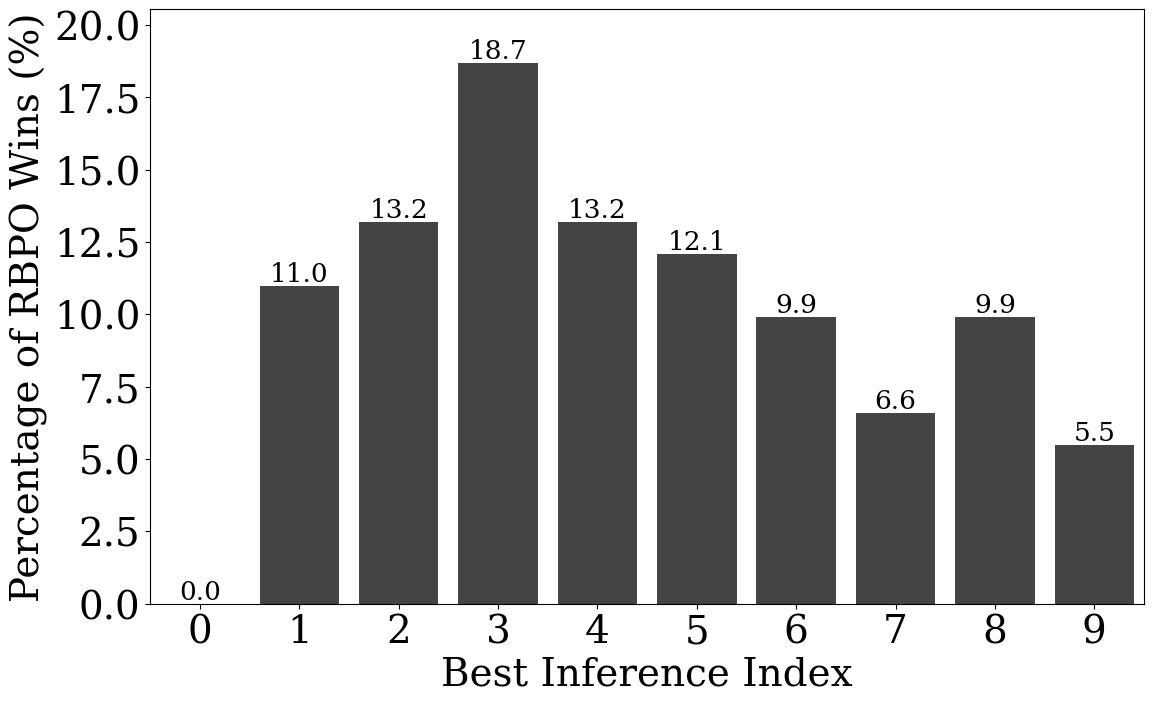

In [133]:
from collections import Counter
import matplotlib.pyplot as plt

font_size = 28

top_k_list = [s["top_k_infer"] for s in all_data if s.get("top_k_infer") is not None]
counter = Counter(top_k_list)

# 👇 ép miền giá trị index từ 0 đến 9
k_min, k_max = 0, 9
items = [(k, counter.get(k, 0)) for k in range(k_min, k_max + 1)]

total = sum(v for _, v in items)
percentages = [(v / total * 100) if total > 0 else 0 for _, v in items]
labels = [str(k) for k, _ in items]

plt.figure(figsize=(12, 7.5))

bars = plt.bar(range(len(labels)), percentages, color=colors[0])

plt.xticks(range(len(labels)), labels, fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.xlabel("Best Inference Index", fontsize=font_size)
plt.ylabel("Percentage of RBPO Wins (%)", fontsize=font_size)

# 👉 Ghi số trên mỗi cột
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,   # nhích nhẹ lên trên
        f"{pct:.1f}",
        ha="center",
        va="bottom",
        fontsize=19
    )

# 👉 gọn lề 2 bên
plt.xlim(-0.5, len(labels) - 0.5)

y_max = max(percentages)
plt.ylim(0, y_max * 1.1)   # chừa thêm 15% khoảng trống

plt.tight_layout()
plt.savefig("figure\\top_k_infer_bpo_rbpo.png", dpi=300, bbox_inches="tight")
plt.show()


# Entropy

In [134]:
case = "bpo_rbpo"
type_name = "merge"
folder_name = "merge"

keys_to_keep = [
    "prompt",
    "bpo_prompt",
    "optimized_prompt",
    "paraphrase_prompts",
    "clusters",
    "cluster_representatives",
    "consensus_scores",
    "cluster_probs",
    "semantic_entropy",
    "conf_score"
]

# output_json = "entr.json"
# output_txt = "summary_top_k_infer_bpo_rbpo.txt"

entropy_res = []
cluster_num_res = []
for d in dataset:
    all_data = []
    for i in base_llm:
        path_jsonl = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\analysis\\{i}\\{d}\\deepseek-chat\\responses_with_semantic.jsonl"
        
        with open(path_jsonl, "r", encoding="utf-8") as f:
            for idx, line in enumerate(f, start=1):
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                entropy_res.append(obj.get("semantic_entropy", 0))
                cluster_num_res.append(len(obj.get("cluster_probs", [])))
                
print(f"Total samples with semantic_entropy: {len(entropy_res)}")
print(f"Total Semantic Entropy Sum: {sum(entropy_res):.4f}")

print(f"Total Cluster Number Sum: {sum(cluster_num_res)}")

Total samples with semantic_entropy: 840
Total Semantic Entropy Sum: 758.3375
Total Cluster Number Sum: 2953


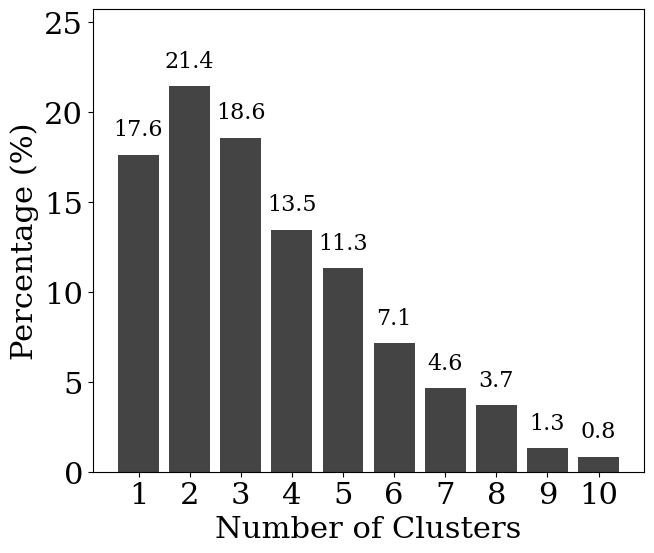

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 22

counts = Counter(cluster_num_res)

x = sorted(counts.keys())
y = np.array([counts[i] for i in x])
y_percent = y / y.sum() * 100

plt.figure(figsize=(7,6))

bars = plt.bar(
    x,
    y_percent,
    color=colors[0],
    # linewidth=0.8
)

plt.xlabel("Number of Clusters")
plt.ylabel("Percentage (%)")

plt.xticks(x)
plt.ylim(0, max(y_percent) * 1.2)


# ----- Add value labels -----
for bar, value in zip(bars, y_percent):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=16
    )

plt.tight_layout()
plt.savefig("figure\\cluster_num_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Average Semantic Entropy across all samples: 0.9028


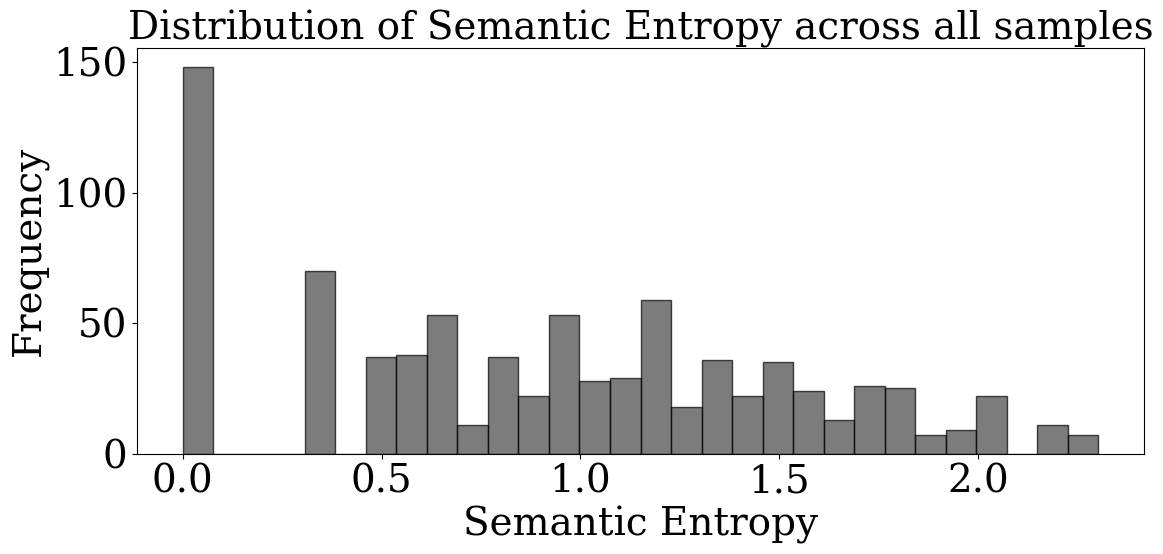

In [136]:
# plot cac gia tri entropy
plt.figure(figsize=(12, 6))
plt.hist(entropy_res, bins=30, color=colors[0], edgecolor="black", alpha=0.7)
plt.xlabel("Semantic Entropy", fontsize=font_size)
plt.ylabel("Frequency", fontsize=font_size)
plt.title("Distribution of Semantic Entropy across all samples", fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.tight_layout()
# plt.savefig("figure\\semantic_entropy_distribution.png", dpi=300, bbox_inches="tight")
print(f"Average Semantic Entropy across all samples: {sum(entropy_res) / (840):.4f}")


# Editting label

Labels and counts:
  Aspect_Expansion: 409
  Depth_Requirement: 160
  Example_Request: 52
  Implication_Expansion: 45
  Instructional_Framing: 388
  Intensification: 110
  Minimal_Change: 138
  Output_Structuring: 70
  Scope_Narrowing: 37
  Secondary_Objective: 163
  Unclear_or_Other: 9
  Verb_Substitution: 135
Saved: ./figure\merged_label_distribution_percent.png


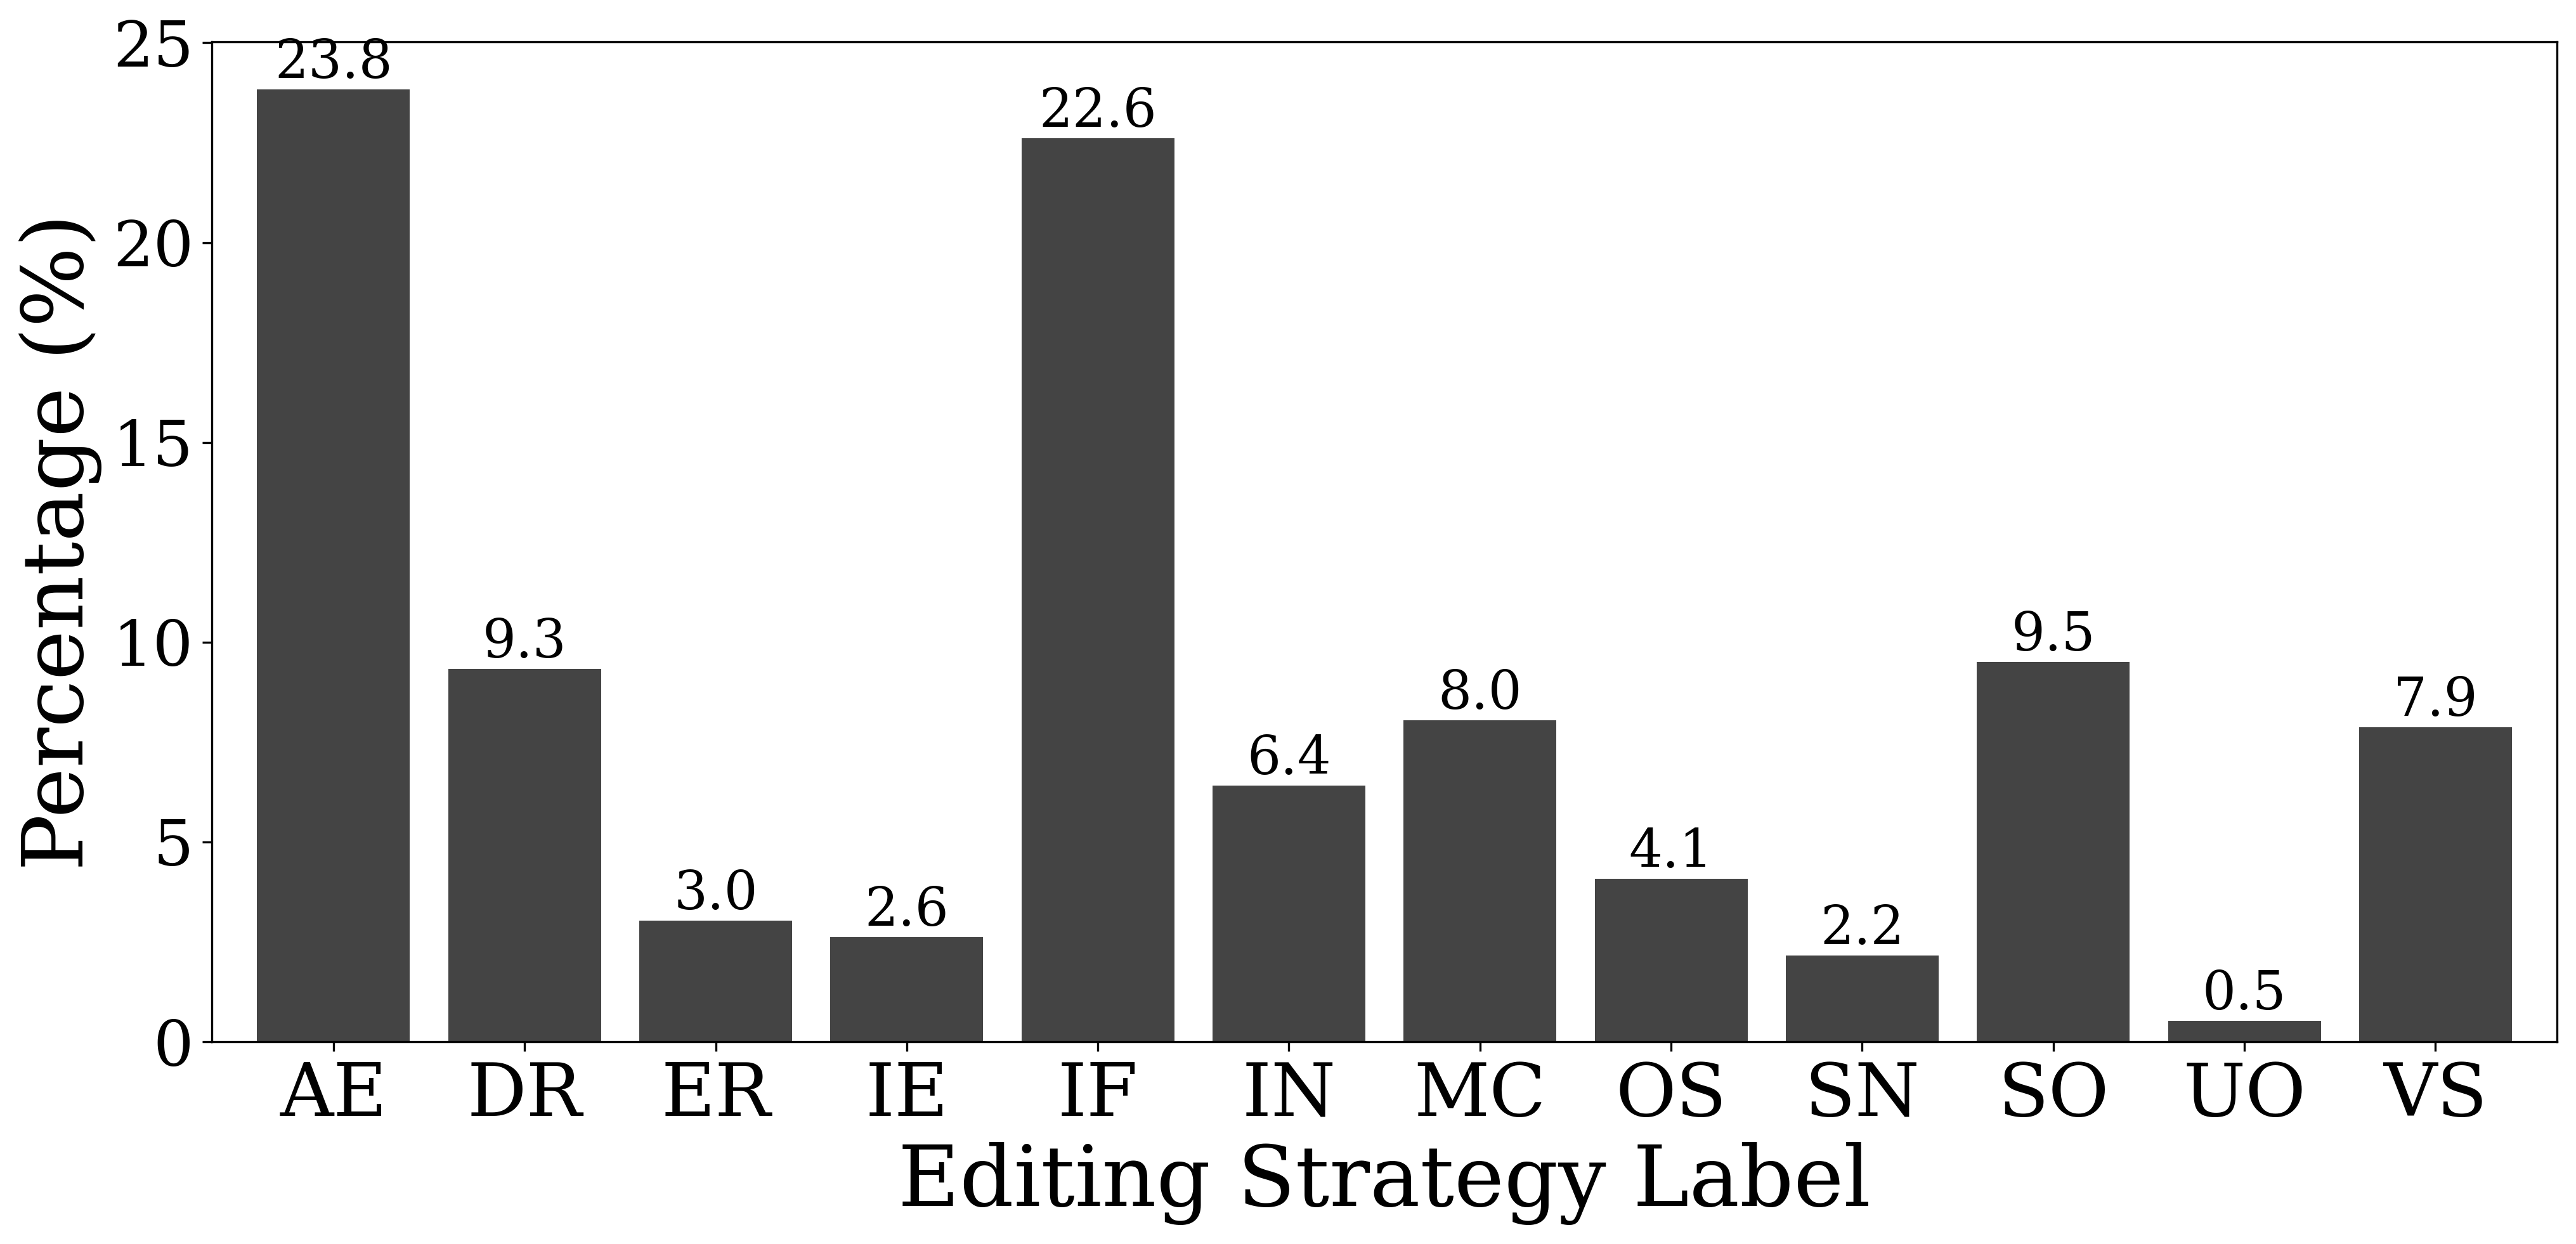

In [137]:
def plot_label_distribution_percent_merged(all_data_list, title, save_name="merged_label_percent.png"):
    from collections import Counter
    import matplotlib.pyplot as plt
    import os

    label_counter = Counter()

    # ---- aggregate labels từ tất cả dataset + model ----
    for all_data in all_data_list:        # mỗi dataset
        for data in all_data:             # mỗi base LLM
            for item in data:             # mỗi sample
                for lb in item["classification"]["labels"]:
                    label_counter[lb] += 1

    # ---- sort theo alphabet ----
    labels = sorted(label_counter.keys())
    print("Labels and counts:")
    for lb in labels:
        print(f"  {lb}: {label_counter[lb]}")
    counts = [label_counter[lb] for lb in labels]
    total = sum(counts)
    percentages = [c / total * 100 for c in counts]

    label_display = [LABEL_ABBR.get(lb, lb) for lb in labels]

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)

    bars = ax.bar(label_display, percentages, color=colors[0], linewidth=1.2)

    ax.set_xlabel("Editing Strategy Label", fontsize=32)
    ax.set_ylabel("Percentage (%)", fontsize=32)
    ax.tick_params(axis="x", labelsize=28)
    ax.tick_params(axis="y", labelsize=24)
    ax.margins(x=0.02)

    # ---- ghi số trên cột ----
    for bar, pct in zip(bars, percentages):
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{pct:.1f}",
            ha="center",
            va="bottom",
            fontsize=20
        )

    fig.tight_layout()

    save_dir = "./figure"
    os.makedirs(save_dir, exist_ok=True)
    fig_path = os.path.join(save_dir, save_name)
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    # plt.close(fig)

    print(f"Saved: {fig_path}")
plot_label_distribution_percent_merged(
    all_data_list,
    title=title,
    save_name="merged_label_distribution_percent.png"
)


# winner_transition_rbpo

In [138]:
import json
import pandas as pd

base_llm = ["Llama-2-7b-chat-hf", "gemma-3-4b-it", "vicuna-7b-v1"]
dataset = ["dolly_eval", "vicuna_eval"]

output_txt = "winner_transition_summary.txt"
output_json = "winner_transition_summary.json"

json_results = []  # lưu toàn bộ kết quả để dump ra json

with open(output_txt, "w", encoding="utf-8") as out:
    for i in base_llm:
        for d in dataset:
            path_1 = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\{folder_name}\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_ori_bpo_{type_name}.json"
            path_2 = f"D:\\Folder F\\phamtuananh@23020010\\UET.iSEML\\Reliable Black-Box Prompt Optimization\\src\\{folder_name}\\{i}\\{d}\\deepseek-chat\\lose_pairwise_results_ori_rbpo_{type_name}.json"
            print(f"Comparing:\n  - {path_1}\n  - {path_2}")

            with open(path_1, "r", encoding="utf-8") as f:
                data_1 = json.load(f)
            with open(path_2, "r", encoding="utf-8") as f:
                data_2 = json.load(f)
                
            df1 = pd.DataFrame(data_1)[["id", "winner"]].rename(columns={"winner": "winner_path_1"})
            df2 = pd.DataFrame(data_2)[["id", "winner"]].rename(columns={"winner": "winner_path_2"})

            merged = df1.merge(df2, on="id", how="inner")

            loss_to_win = ((merged["winner_path_1"] == 0) & (merged["winner_path_2"] == 1)).sum()
            loss_to_tie = ((merged["winner_path_1"] == 0) & (merged["winner_path_2"] == 2)).sum()
            tie_to_win  = ((merged["winner_path_1"] == 2) & (merged["winner_path_2"] == 1)).sum()

            total = len(merged)
            total_improvements = loss_to_win + tie_to_win
            improvement_rate = total_improvements / total if total > 0 else 0.0

            # ===== TXT =====
            out.write("=" * 80 + "\n")
            out.write(f"Base LLM : {i}\n")
            out.write(f"Dataset  : {d}\n")
            out.write(f"Total pairs: {total}\n\n")

            out.write("Transition counts:\n")
            out.write(f"  loss → win (0→1): {loss_to_win}\n")
            out.write(f"  loss → tie (0→2): {loss_to_tie}\n")
            out.write(f"  tie  → win (2→1): {tie_to_win}\n\n")

            out.write("Improvement summary:\n")
            out.write(f"  Total improvements (0→1 + 2→1): {total_improvements}\n")
            out.write(f"  Improvement rate: {improvement_rate:.2%}\n\n")

            # ===== JSON =====
            json_results.append({
                "base_llm": i,
                "dataset": d,
                "total_pairs": total,
                "loss_to_win": int(loss_to_win),
                "loss_to_tie": int(loss_to_tie),
                "tie_to_win": int(tie_to_win),
                "total_improvements": int(total_improvements),
                "improvement_rate": improvement_rate
            })

# Ghi JSON ra file
with open(output_json, "w", encoding="utf-8") as jf:
    json.dump(json_results, jf, indent=2, ensure_ascii=False)

print(f"Đã lưu kết quả vào:")
print(f"  - TXT : {output_txt}")
print(f"  - JSON: {output_json}")


Comparing:
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\Llama-2-7b-chat-hf\dolly_eval\deepseek-chat\lose_pairwise_results_ori_bpo_merge.json
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\Llama-2-7b-chat-hf\dolly_eval\deepseek-chat\lose_pairwise_results_ori_rbpo_merge.json
Comparing:
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\Llama-2-7b-chat-hf\vicuna_eval\deepseek-chat\lose_pairwise_results_ori_bpo_merge.json
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\Llama-2-7b-chat-hf\vicuna_eval\deepseek-chat\lose_pairwise_results_ori_rbpo_merge.json
Comparing:
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-Box Prompt Optimization\src\merge\gemma-3-4b-it\dolly_eval\deepseek-chat\lose_pairwise_results_ori_bpo_merge.json
  - D:\Folder F\phamtuananh@23020010\UET.iSEML\Reliable Black-B

In [139]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load summary JSON
with open("winner_transition_summary.json", "r", encoding="utf-8") as f:
    results = json.load(f)

# Chuẩn hóa tên model cho plot
model_name_map = {
    "Llama-2-7b-chat-hf": "llama-2-7B-chat",
    "vicuna-7b-v1": "vicuna-7B-v1.3",
    "gemma-3-4b-it": "Gemma-3-4B-IT"
}

models = ["llama-2-7B-chat", "vicuna-7B-v1.3", "Gemma-3-4B-IT"]
datasets = ["vicuna_eval", "dolly_eval"]

# Tạo dict: dataset → transition → list
plot_data = {}

for d in datasets:
    plot_data[d] = {
        "loss_to_tie": [],
        "loss_to_win": [],
        "tie_to_win": []
    }
    for m in model_name_map:
        for r in results:
            if r["base_llm"] == m and r["dataset"] == d:
                plot_data[d]["loss_to_tie"].append(r["loss_to_tie"])
                plot_data[d]["loss_to_win"].append(r["loss_to_win"])
                plot_data[d]["tie_to_win"].append(r["tie_to_win"])


In [140]:
# import matplotlib.pyplot as plt
# import numpy as np

# # ---- style cho 3 nhóm ----
# colors = ["#c0392b", "#2c3e50", "#27ae60"]
# hatches = ["||", "\\\\", "//"]
# legends = ["Model 1", "Model 2", "Model 3"] 

# x = np.arange(len(models))
# width = 0.25

# fig, axes = plt.subplots(
#     1, 2,
#     figsize=(12, 4.5),
#     sharey=True,
#     dpi=300
# )

# for idx, d in enumerate(datasets):
#     ax = axes[idx]

#     ax.bar(x - width, plot_data[d]["loss_to_tie"], width, label="Loss → Tie")
#     ax.bar(x,         plot_data[d]["loss_to_win"], width, label="Loss → Win")
#     ax.bar(x + width, plot_data[d]["tie_to_win"],  width, label="Tie → Win")

#     ax.set_title(
#         d.replace("_", " ").title(),
#         fontsize=14          # 👈 title to hơn
#     )

#     ax.set_xticks(x)
#     ax.set_xticklabels(
#         models,
#         rotation=0,
#         fontsize=12          # 👈 x-tick
#     )

#     ax.tick_params(axis="y", labelsize=11)   # 👈 y-tick
#     ax.grid(axis="y", linestyle="--", alpha=0.4)

#     ax.legend(fontsize=11)   # 👈 legend

# axes[0].set_ylabel("Count", fontsize=13)     # 👈 ylabel

# plt.tight_layout(rect=[0, 0, 1, 0.95])

# output_fig = "figure\\winner_transition_rbpo.png"
# plt.savefig(output_fig, dpi=300, bbox_inches="tight")
# plt.show()

# print(f"Figure saved to: {output_fig}")

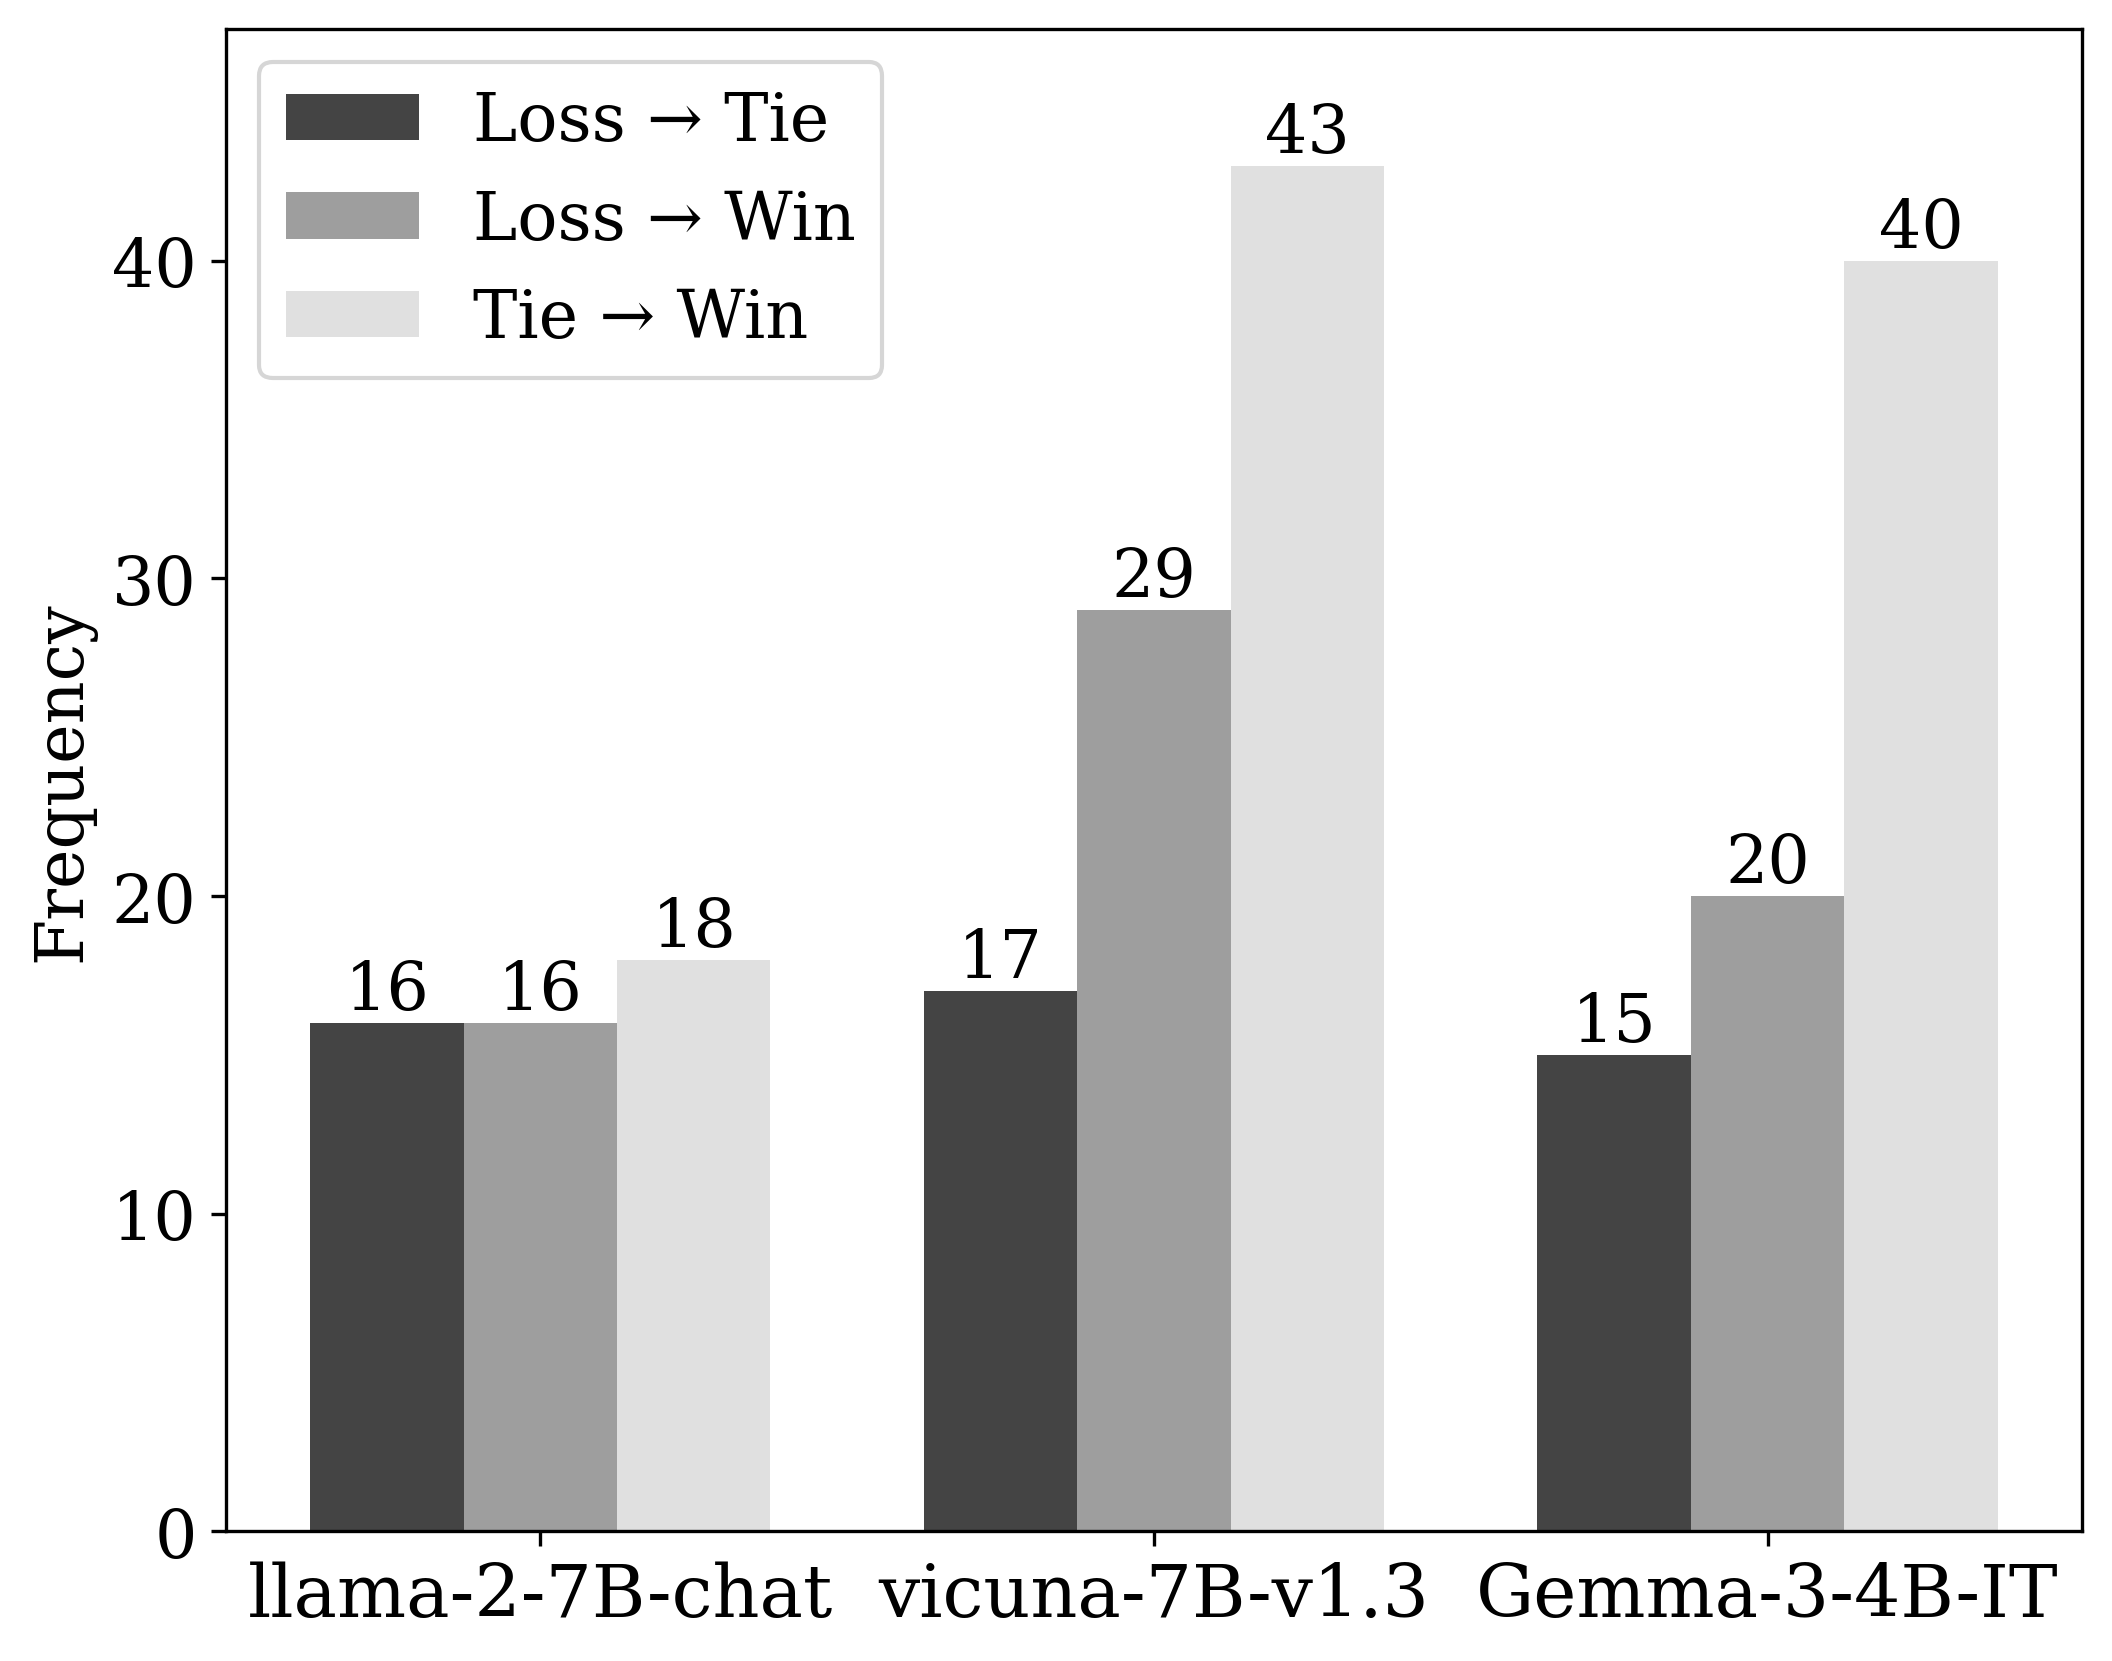

Figure saved to: figure\winner_transition_rbpo.png


In [141]:
import matplotlib.pyplot as plt
import numpy as np

# ---- style cho 3 nhóm ----
# colors = ["#c0392b", "#2c3e50", "#27ae60"]
# colors = ["#000000", "#b0b0b0", "#ffffff"]
colors = ["#444444", "#9e9e9e", "#e0e0e0"]

# colors = ["#ffffff", "#ffffff", "#ffffff"]

# hatches = ["||", "\\\\", "//"]
hatches = ["", "", ""]

legends = ["Loss → Tie", "Loss → Win", "Tie → Win"]

x = np.arange(len(models))
width = 0.25

# ---- aggregate 2 datasets ----
agg_loss_to_tie = (
    np.array(plot_data["dolly_eval"]["loss_to_tie"]) +
    np.array(plot_data["vicuna_eval"]["loss_to_tie"])
)
agg_loss_to_win = (
    np.array(plot_data["dolly_eval"]["loss_to_win"]) +
    np.array(plot_data["vicuna_eval"]["loss_to_win"])
)
agg_tie_to_win = (
    np.array(plot_data["dolly_eval"]["tie_to_win"]) +
    np.array(plot_data["vicuna_eval"]["tie_to_win"])
)

# ---- plot ----
fig, ax = plt.subplots(figsize=(7.5, 6), dpi=300)

# nền xám
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

bars1 = ax.bar(
    x - width, agg_loss_to_tie, width,
    label=legends[0],
    color=colors[0],
    # edgecolor="black",
    hatch=hatches[0]
)

bars2 = ax.bar(
    x, agg_loss_to_win, width,
    label=legends[1],
    color=colors[1],
    # edgecolor="black",
    hatch=hatches[1]
)

bars3 = ax.bar(
    x + width, agg_tie_to_win, width,
    label=legends[2],
    color=colors[2],
    # edgecolor="black",
    hatch=hatches[2]
)

# ax.set_title("Aggregated Winner Transitions (Dolly + Vicuna)", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=17.5)

ax.set_ylabel("Frequency", fontsize=16)
ax.tick_params(axis="y", labelsize=16)
# ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.legend(fontsize=16)

y_max = max(
    agg_loss_to_tie.max(),
    agg_loss_to_win.max(),
    agg_tie_to_win.max()
)

ax.set_ylim(0, y_max * 1.1)   # thêm 15% khoảng trống phía trên

# ---- hiện số trên từng cột ----
def autolabel(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=16
        )

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

plt.tight_layout()
output_fig = "figure\\winner_transition_rbpo.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {output_fig}")
